# Análise exploratória de proxies de demanda (ABCR + IBGE)

O notebook descreve dois proxies de demanda, úteis na defasagem de cerca de dois meses das vendas ANP e Petrobras:

- **Índice de tráfego ABCR** (`abcr_traffic_index`): leve acompanha gasolina; pesado acompanha diesel de frete.
- **Indicadores SIDRA do IBGE** (`ibge_indicators`): volume do varejo e produção industrial acompanham mobilidade e carga.

A pergunta é se essas séries antecipam ou acompanham as vendas mensais da ANP (`anp_fuel_sales`).


In [ ]:
import sys
from pathlib import Path

from IPython.display import display

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use('seaborn-v0_8')

cwd = Path.cwd().resolve()
if (cwd / 'src').is_dir() and (cwd / 'data').is_dir():
    project_root = cwd
elif (cwd.parent / 'src').is_dir() and (cwd.parent / 'data').is_dir():
    project_root = cwd.parent
else:
    raise FileNotFoundError(
        'Could not locate proj_IV root (expected src/ and data/). '
        'Open notebooks from proj_IV/ or proj_IV/notebooks/.'
    )

sys.path.insert(0, str(project_root / 'src'))

from db_access import read_engine, resolve_database_url

ENGINE = read_engine(project_root)
DATABASE_URL = resolve_database_url(project_root)
DATABASE_URL

In [2]:
def read_table(engine, sql):
    """Read a query, returning an empty frame if the table does not exist yet."""
    try:
        return pd.read_sql_query(sql, engine)
    except Exception as exc:
        print(f'Skipping query ({exc})')
        return pd.DataFrame()

abcr_query = 'SELECT month, vehicle_type, traffic_index FROM abcr_traffic_index ORDER BY month, vehicle_type'
ibge_query = 'SELECT indicator_code, indicator_name, month, value, unit FROM ibge_indicators ORDER BY month, indicator_code'
anp_query = 'SELECT product, month, volume_m3 FROM anp_fuel_sales ORDER BY month, product'

abcr = read_table(ENGINE, abcr_query)
ibge = read_table(ENGINE, ibge_query)
anp = read_table(ENGINE, anp_query)
ppi_anchor = pd.to_datetime(
    pd.read_sql_query('SELECT MIN(report_date) AS d FROM ppi_daily', ENGINE).iloc[0, 0]
)

for df in (abcr, ibge, anp):
    if not df.empty:
        df['month'] = pd.to_datetime(df['month'], errors='coerce')
if not abcr.empty:
    abcr = abcr[abcr['month'] >= ppi_anchor].copy()
if not ibge.empty:
    ibge = ibge[ibge['month'] >= ppi_anchor].copy()
if not anp.empty:
    anp = anp[anp['month'] >= ppi_anchor].copy()
print(f'PPI anchor: {ppi_anchor.date()}')

product_label = {'diesel': 'Diesel', 'gasolina_c': 'Gasoline C'}
if not anp.empty:
    anp['product_label'] = anp['product'].map(product_label).fillna(anp['product'])

# Wide pivots for plotting (guarded).
abcr_wide = abcr.pivot_table(index='month', columns='vehicle_type', values='traffic_index') if not abcr.empty else pd.DataFrame()
ibge_wide = ibge.pivot_table(index='month', columns='indicator_code', values='value') if not ibge.empty else pd.DataFrame()
abcr.head()

PPI anchor: 2022-01-05


,month,vehicle_type,traffic_index
0,2022-02-01,heavy,106.600969
1,2022-02-01,light,117.570924
2,2022-02-01,total,115.899981
3,2022-03-01,heavy,120.717911
4,2022-03-01,light,140.870414


In [3]:
def span(df, col='month'):
    if df.empty:
        return (pd.NaT, pd.NaT)
    return (df[col].min(), df[col].max())

summary = pd.DataFrame({
    'rows': [len(abcr), len(ibge), len(anp)],
    'categories': [
        abcr['vehicle_type'].nunique() if not abcr.empty else 0,
        ibge['indicator_code'].nunique() if not ibge.empty else 0,
        anp['product'].nunique() if not anp.empty else 0,
    ],
    'min_month': [span(abcr)[0], span(ibge)[0], span(anp)[0]],
    'max_month': [span(abcr)[1], span(ibge)[1], span(anp)[1]],
}, index=['abcr_traffic_index', 'ibge_indicators', 'anp_fuel_sales'])

if anp.empty and abcr.empty and ibge.empty:
    print('All source tables are empty. Run the predictors pipeline (abcr / ibge / anp) first.')
summary

,rows,categories,min_month,max_month
abcr_traffic_index,156,3,2022-02-01,2026-05-01
ibge_indicators,153,3,2022-02-01,2026-04-01
anp_fuel_sales,102,2,2022-02-01,2026-04-01


In [4]:
def count_missing_months(series: pd.Series) -> int:
    s = series.dropna()
    if s.empty:
        return 0
    expected = pd.date_range(s.min(), s.max(), freq='MS')
    observed = pd.DatetimeIndex(s.unique()).sort_values()
    return len(expected.difference(observed))

quality_rows = []
if not abcr.empty:
    for vt, g in abcr.groupby('vehicle_type'):
        quality_rows.append({
            'source': 'ABCR', 'series': vt, 'rows': len(g),
            'null_value': int(g['traffic_index'].isna().sum()),
            'non_positive': int((g['traffic_index'] <= 0).sum()),
            'dupes': int(g.duplicated(subset=['vehicle_type', 'month']).sum()),
            'missing_months': count_missing_months(g['month']),
        })
if not ibge.empty:
    for code, g in ibge.groupby('indicator_code'):
        quality_rows.append({
            'source': 'IBGE', 'series': f"{code} {g['indicator_name'].iloc[0]}", 'rows': len(g),
            'null_value': int(g['value'].isna().sum()),
            'non_positive': int((g['value'] <= 0).sum()),
            'dupes': int(g.duplicated(subset=['indicator_code', 'month']).sum()),
            'missing_months': count_missing_months(g['month']),
        })

pd.DataFrame(quality_rows) if quality_rows else 'No proxy data to profile yet.'

,source,series,rows,null_value,non_positive,dupes,missing_months
0,ABCR,heavy,52,0,0,0,0
1,ABCR,light,52,0,0,0,0
2,ABCR,total,52,0,0,0,0
3,IBGE,6381 Unemployment Rate (PNAD),51,0,0,0,0
4,IBGE,8880 Retail Trade Volume Index (PMC),51,0,0,0,0
5,IBGE,8888 Industrial Production Index (PIM-PF),51,0,0,0,0


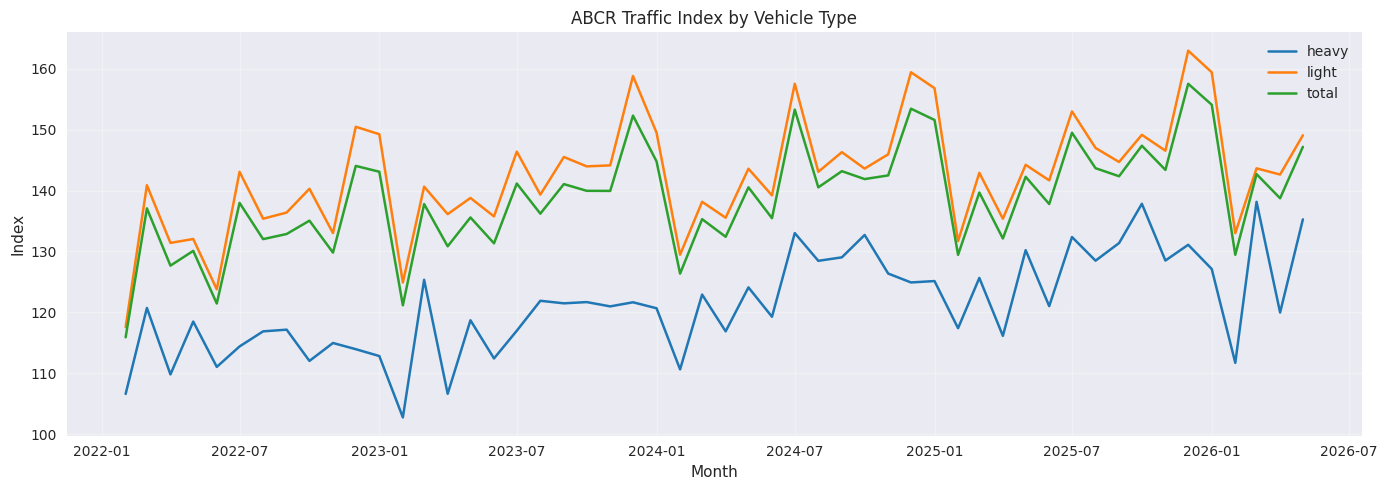

In [5]:
if abcr_wide.empty:
    print('ABCR table empty - run: python -m src.predictors.pipeline abcr')
else:
    fig, ax = plt.subplots(figsize=(14, 5))
    colors = {'light': '#ff7f0e', 'heavy': '#1f77b4', 'total': '#2ca02c'}
    for col in abcr_wide.columns:
        ax.plot(abcr_wide.index, abcr_wide[col], linewidth=1.8, label=col, color=colors.get(col))
    ax.set_title('ABCR Traffic Index by Vehicle Type')
    ax.set_xlabel('Month')
    ax.set_ylabel('Index')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')
    plt.tight_layout()
    plt.show()

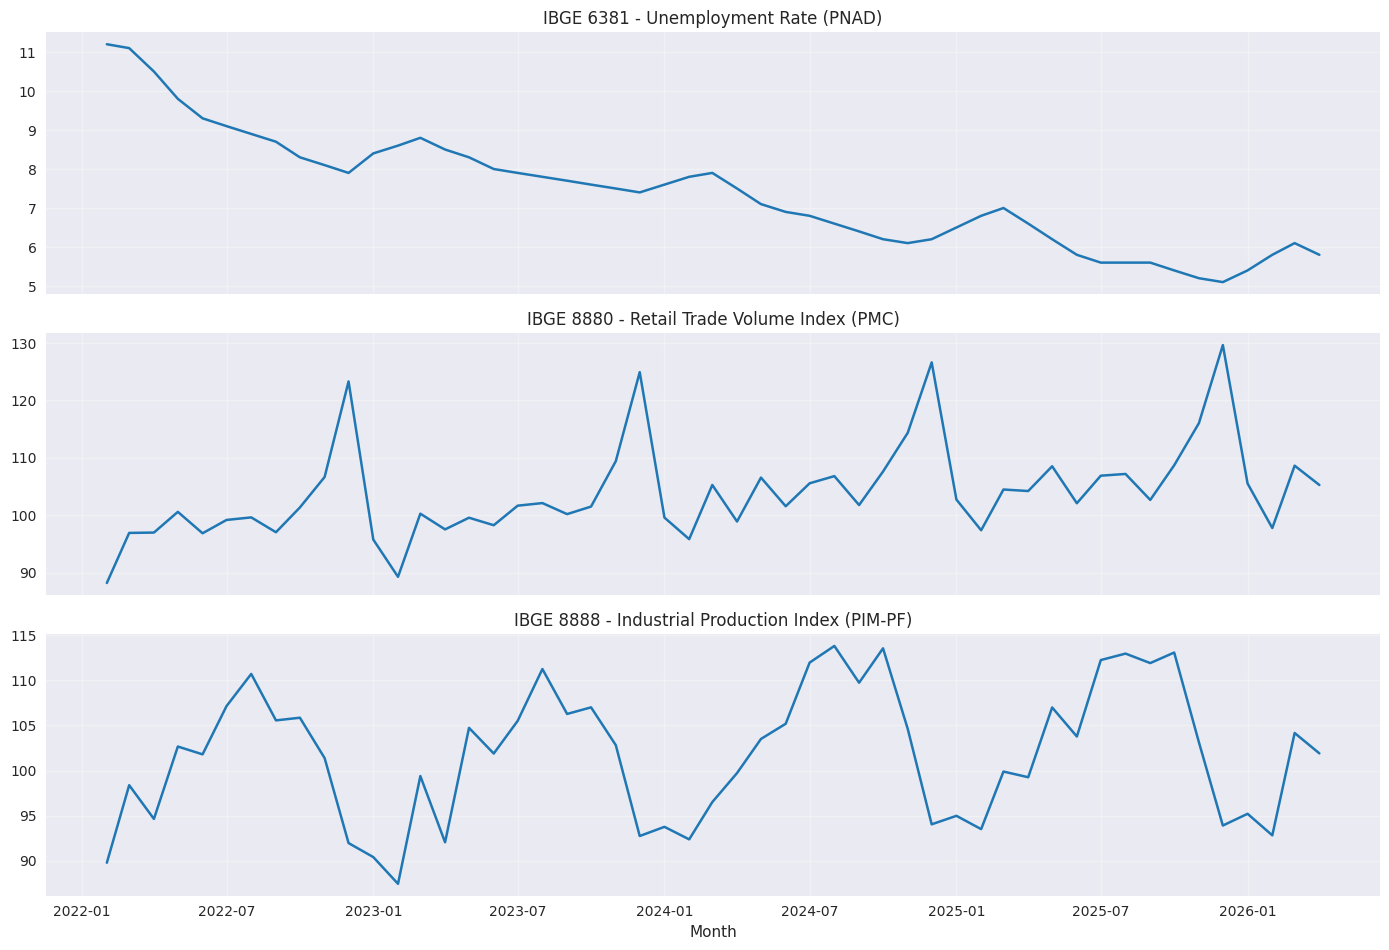

In [6]:
if ibge_wide.empty:
    print('IBGE table empty - run: python -m src.predictors.pipeline ibge')
else:
    name_by_code = ibge.drop_duplicates('indicator_code').set_index('indicator_code')['indicator_name'].to_dict()
    fig, axes = plt.subplots(len(ibge_wide.columns), 1, figsize=(14, 3.2 * len(ibge_wide.columns)), sharex=True)
    axes = np.atleast_1d(axes)
    for ax, code in zip(axes, ibge_wide.columns):
        ax.plot(ibge_wide.index, ibge_wide[code], linewidth=1.8, color='#1f77b4')
        ax.set_title(f"IBGE {code} - {name_by_code.get(code, code)}")
        ax.grid(True, alpha=0.3)
    axes[-1].set_xlabel('Month')
    plt.tight_layout()
    plt.show()

## Proxy contra vendas ANP

Cada proxy é reescalado para média 100 e traçado contra o volume ANP correspondente (também reescalado), em eixos gêmeos. A tese visual: ABCR **pesado** acompanha **diesel**; ABCR **leve** acompanha **gasolina**, de preferência algumas semanas à frente.


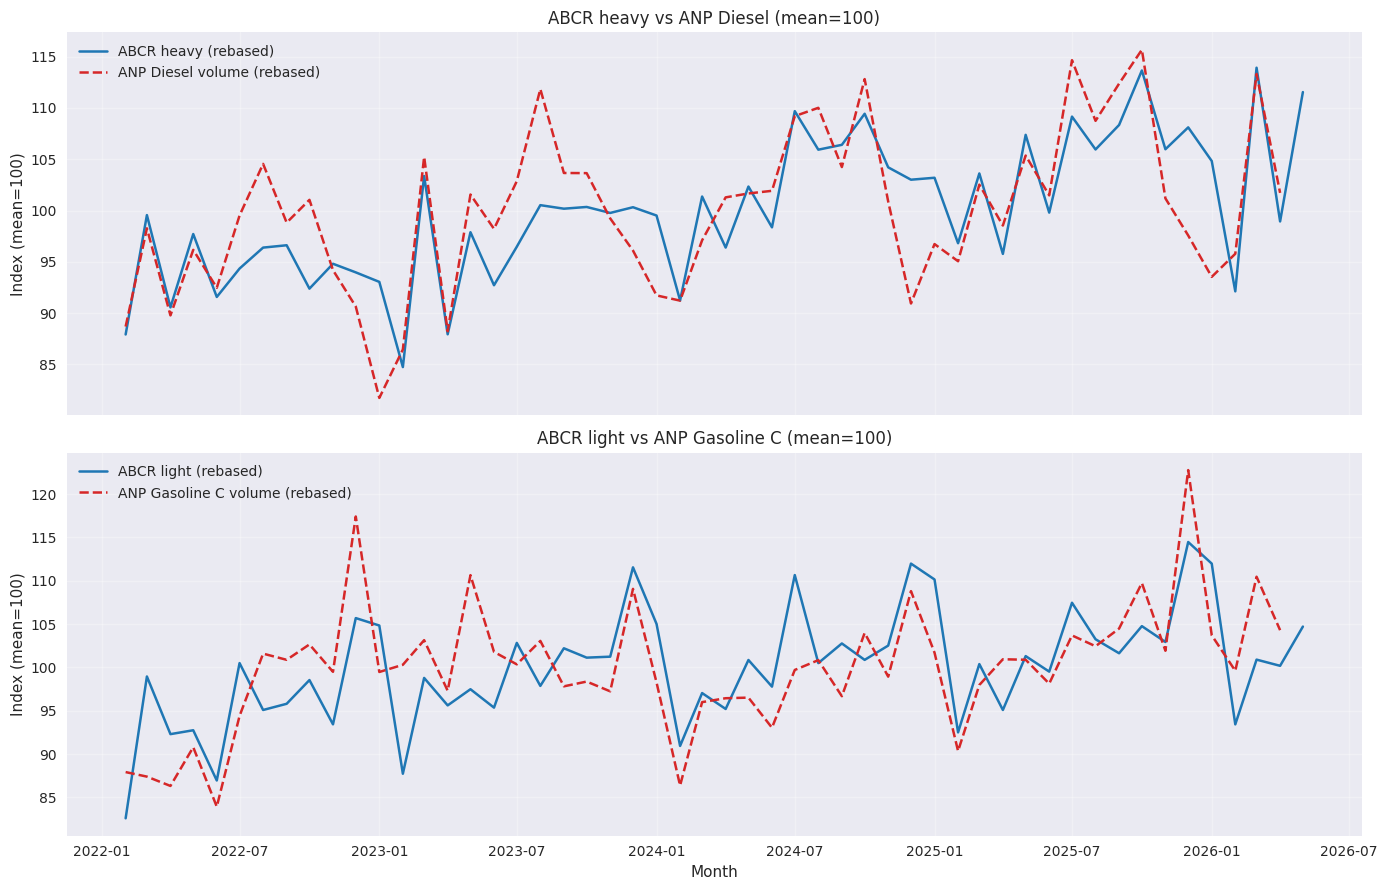

In [7]:
def rebase(s):
    s = s.dropna()
    return s / s.mean() * 100.0 if not s.empty and s.mean() else s

pairs = [('heavy', 'diesel', 'Diesel'), ('light', 'gasolina_c', 'Gasoline C')]

if abcr_wide.empty or anp.empty:
    print('Need both ABCR and ANP data for the overlay. Populate both tables first.')
else:
    fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
    for ax, (vt, product, label) in zip(axes, pairs):
        if vt in abcr_wide.columns:
            ax.plot(abcr_wide.index, rebase(abcr_wide[vt]), color='#1f77b4', linewidth=1.8, label=f'ABCR {vt} (rebased)')
        g = anp[anp['product'] == product].set_index('month')['volume_m3']
        if not g.empty:
            ax.plot(g.index, rebase(g), color='#d62728', linewidth=1.8, linestyle='--', label=f'ANP {label} volume (rebased)')
        ax.set_title(f'ABCR {vt} vs ANP {label} (mean=100)')
        ax.set_ylabel('Index (mean=100)')
        ax.grid(True, alpha=0.3)
        ax.legend(loc='best')
    axes[-1].set_xlabel('Month')
    plt.tight_layout()
    plt.show()

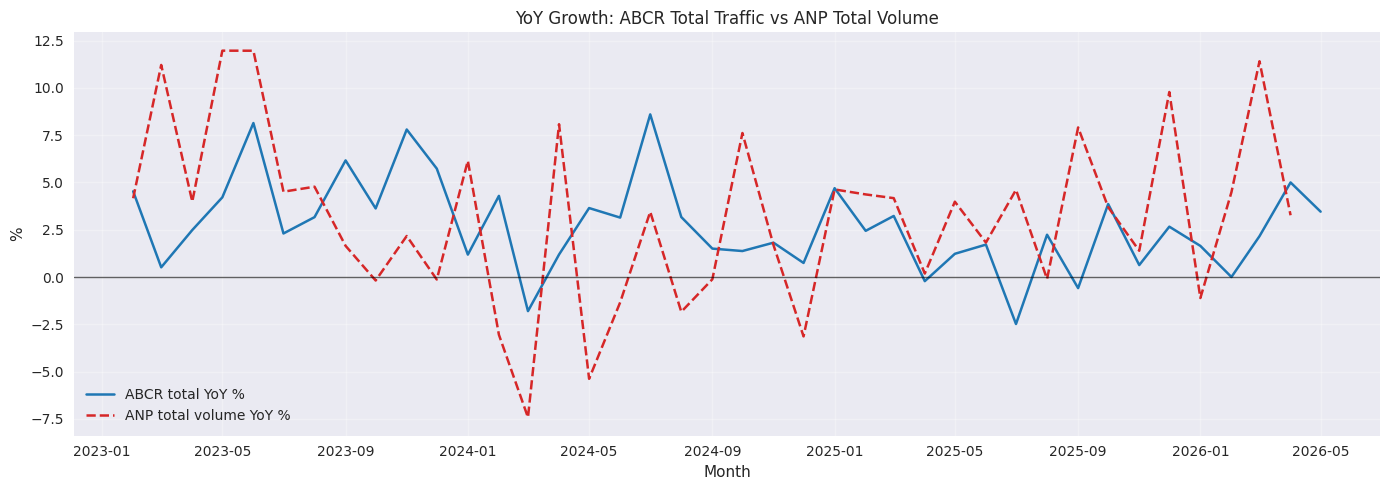

In [8]:
# YoY growth: ABCR total vs ANP total volume, a like-for-like momentum comparison.
if abcr_wide.empty or anp.empty:
    print('Need both ABCR and ANP data for the YoY comparison.')
else:
    fig, ax = plt.subplots(figsize=(14, 5))
    if 'total' in abcr_wide.columns:
        abcr_yoy = abcr_wide['total'].pct_change(12) * 100.0
        ax.plot(abcr_yoy.index, abcr_yoy, color='#1f77b4', linewidth=1.8, label='ABCR total YoY %')
    anp_total = anp.groupby('month')['volume_m3'].sum()
    anp_yoy = anp_total.pct_change(12) * 100.0
    ax.plot(anp_yoy.index, anp_yoy, color='#d62728', linewidth=1.8, linestyle='--', label='ANP total volume YoY %')
    ax.axhline(0.0, color='black', linewidth=1.0, alpha=0.6)
    ax.set_title('YoY Growth: ABCR Total Traffic vs ANP Total Volume')
    ax.set_xlabel('Month')
    ax.set_ylabel('%')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best')
    plt.tight_layout()
    plt.show()